In [471]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [472]:
sample_size= 100000

# No normalization

## Problem set-up

2 inputs

$\theta=\left( A, B \right)$

3 model observables

$f(\theta) = \begin{pmatrix}
A+B \\
3A-2B \\
4A+B
\end{pmatrix}$

Extra knowledge on model observables

$E = \begin{pmatrix}
C1 \\
C2 \\
C3
\end{pmatrix}$

## Define inputs

A: $\mathbb{R}$

B: $\mathbb{R}$

Draw sample {A} of A, and {B} of B

In [473]:
A = np.random.normal(1.5, 5/100 * 1.5, sample_size)
B = np.random.normal(2, 8/100 * 2, sample_size)

## Define model

f: $\mathbb{R}^2 \rightarrow \mathbb{R}^3$ 

In [474]:
def foo(A, B):
    C1 = A + B
    C2 = 3*A - 2*B
    C3 = 4*A + B
    return np.array([C1, C2, C3])

In [475]:
f = foo(A, B)

## Analyze output sample

In [476]:
out = pd.DataFrame({
    "A": A,
    "B": B,
    "C1": f[0],
    "C2": f[1],
    "C3": f[2],
})

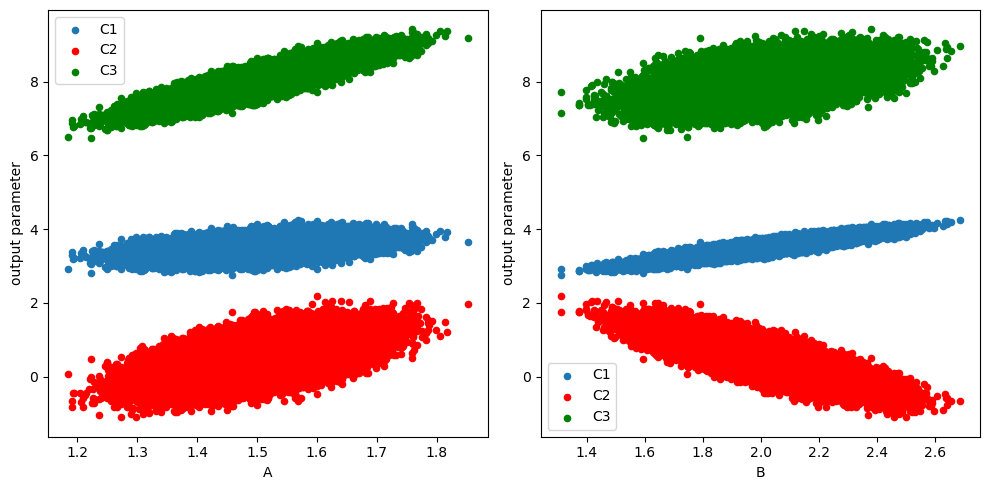

In [477]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

ax = axs[0]
out.plot.scatter(x="A", y="C1", ax=ax, label="C1")
out.plot.scatter(x="A", y="C2", color="red", ax=ax, label="C2")
out.plot.scatter(x="A", y="C3", color="green", ax=ax, label="C3")
ax.set(ylabel="output parameter")

ax = axs[1]
out.plot.scatter(x="B", y="C1", ax=ax, label="C1")
out.plot.scatter(x="B", y="C2", color="red", ax=ax, label="C2")
out.plot.scatter(x="B", y="C3", color="green", ax=ax, label="C3")
ax.set(ylabel="output parameter")

ax.legend()
fig.tight_layout()

## Set up extra data

In [478]:
E = np.array([3, 1, 10])
STD_E = 2 / 100 * E
COV_E = np.diag(STD_E**2)

In [479]:
r = E - f.T
chi2 = np.sum(r**2 / STD_E**2, axis=1)

In [480]:
w = np.exp(-0.5 * chi2)
w /= w.sum()

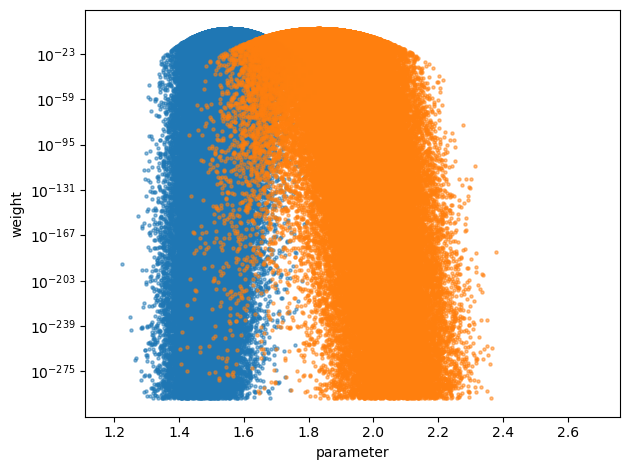

In [481]:
fig, ax = plt.subplots()
ax.scatter(A, w, s=5, alpha=.5)
ax.scatter(B, w, s=5, alpha=.5)
ax.set(yscale="log", xlabel="parameter", ylabel="weight")
fig.tight_layout()

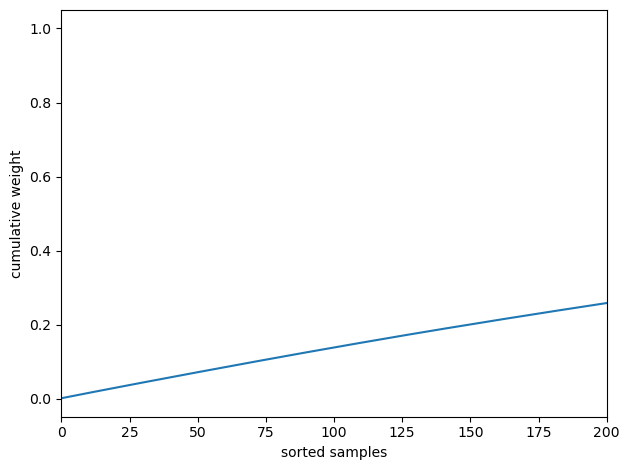

In [482]:
fig, ax = plt.subplots()
w_sorted = np.sort(w)[::-1]
ax.plot(np.cumsum(w_sorted))
ax.set(xlabel="sorted samples", ylabel="cumulative weight", xlim=[0, 200])
fig.tight_layout()

In [483]:
A_post_mean = np.sum(w * A)
A_post_std = np.sqrt(np.sum(w * (A - A_post_mean)**2))

print(
    A_post_mean,
    A_post_std / A_post_mean * 100
)

B_post_mean = np.sum(w * B)
B_post_std = np.sqrt(np.sum(w * (B - B_post_mean)**2))

print(
    B_post_mean,
    B_post_std / B_post_mean * 100
)

cov_AB = np.sum(w * (A - A_post_mean) * (B - B_post_mean))
corr_AB = cov_AB / (A_post_std * B_post_std)
print(corr_AB)

1.5559951265307106 1.24618347914525
1.8290597379305824 1.588994725819291
0.940485453531412


<Axes: >

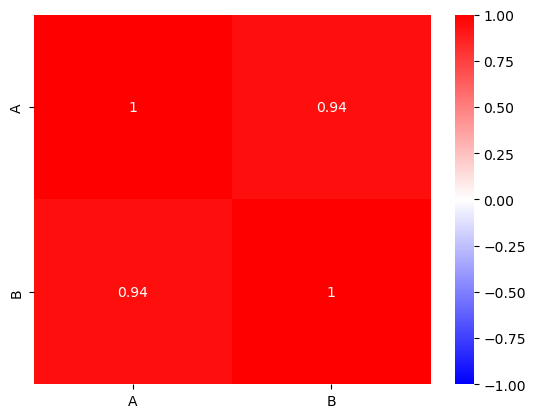

In [484]:
corr_matrix = pd.DataFrame([
    [1,       corr_AB],
    [corr_AB, 1,     ],
], index=["A", "B"], columns=["A", "B"])
sns.heatmap(corr_matrix, cmap="bwr", vmin=-1, vmax=1, annot=True)

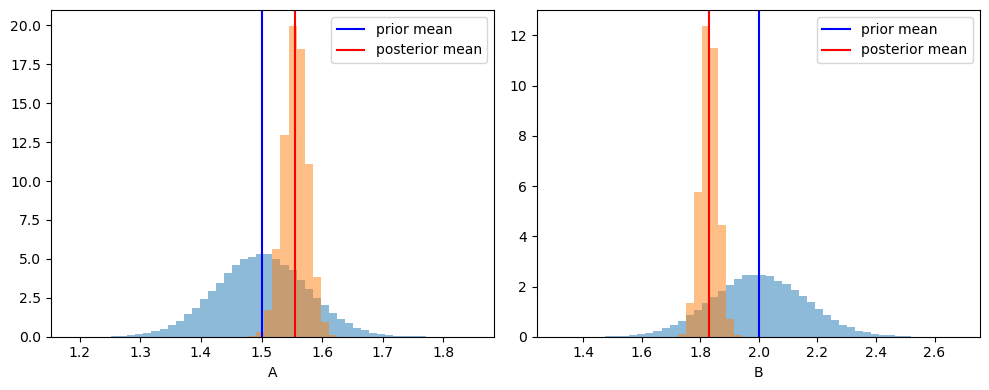

In [485]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

ax = axs[0]
ax.hist(A, bins=50, density=True, alpha=.5)
ax.hist(A, bins=50, weights=w, density=True, alpha=.5)
ax.axvline(np.mean(A), color='b', label='prior mean')
ax.axvline(np.sum(w * A), color='r', label='posterior mean')
ax.set(xlabel="A")
ax.legend(loc=1)

ax = axs[1]
ax.hist(B, bins=50, density=True, alpha=.5)
ax.hist(B, bins=50, weights=w, density=True, alpha=.5)
ax.axvline(np.mean(B), color='b', label='prior mean')
ax.axvline(np.sum(w * B), color='r', label='posterior mean')
ax.set(xlabel="B")
ax.legend(loc=1)

fig.tight_layout()

# With normalization

## Problem set-up

3 inputs

$\theta=\left( A, B, N \right)$

4 model observables

$f(\theta) = \begin{pmatrix}
N(A+B) \\
N(3A-2B) \\
N(4A+B)\\
N
\end{pmatrix}$

Extra knowledge on model observables

$E = \begin{pmatrix}
C1 \\
C2 \\
C3 \\
C4
\end{pmatrix}$

## Define inputs

A: $\mathbb{R}$

B: $\mathbb{R}$

N: $\mathbb{R}$

Draw sample {A} of A, and {B} of B, and {N} of N

In [486]:
A = np.random.normal(1.5, 5/100 * 1.5, sample_size)
B = np.random.normal(2, 8/100 * 2, sample_size)
N = np.random.normal(1, 10/100 * 1, sample_size)

## Define model

f: $\mathbb{R}^3 \rightarrow \mathbb{R}^4$ 

In [487]:
def foo(A, B, N):
    C1 = N*(A + B)
    C2 = N*(3*A - 2*B)
    C3 = N*(4*A + B)
    C4 = N
    return np.array([C1, C2, C3, N])

In [488]:
f = foo(A, B, N)

## Analyze output sample

In [489]:
out = pd.DataFrame({
    "A": A,
    "B": B,
    "N": N,
    "C1": f[0],
    "C2": f[1],
    "C3": f[2],
    "C4": f[3],
})

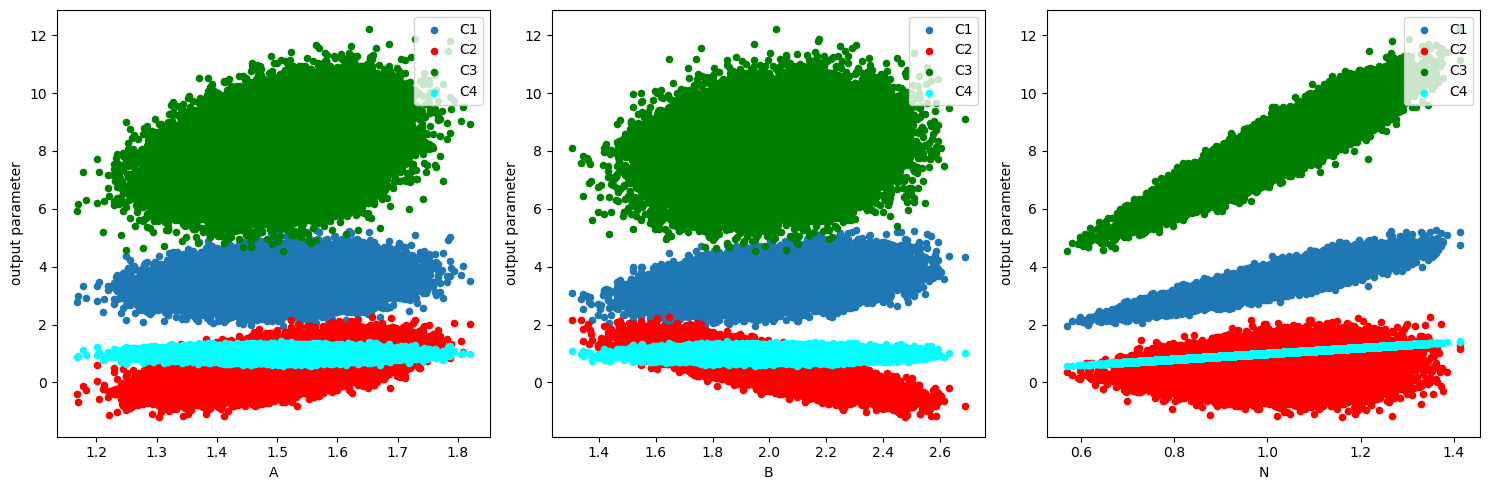

In [490]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

ax = axs[0]
out.plot.scatter(x="A", y="C1", ax=ax, label="C1")
out.plot.scatter(x="A", y="C2", color="red", ax=ax, label="C2")
out.plot.scatter(x="A", y="C3", color="green", ax=ax, label="C3")
out.plot.scatter(x="A", y="C4", color="cyan", ax=ax, label="C4")
ax.set(ylabel="output parameter")
ax.legend(loc=1)

ax = axs[1]
out.plot.scatter(x="B", y="C1", ax=ax, label="C1")
out.plot.scatter(x="B", y="C2", color="red", ax=ax, label="C2")
out.plot.scatter(x="B", y="C3", color="green", ax=ax, label="C3")
out.plot.scatter(x="B", y="C4", color="cyan", ax=ax, label="C4")
ax.set(ylabel="output parameter")
ax.legend(loc=1)

ax = axs[2]
out.plot.scatter(x="N", y="C1", ax=ax, label="C1")
out.plot.scatter(x="N", y="C2", color="red", ax=ax, label="C2")
out.plot.scatter(x="N", y="C3", color="green", ax=ax, label="C3")
out.plot.scatter(x="N", y="C4", color="cyan", ax=ax, label="C4")
ax.set(ylabel="output parameter")
ax.legend(loc=1)

fig.tight_layout()

## Set up extra data

In [491]:
E = np.array([3, 1, 10, 1])
STD_E = 2 / 100 * E
COV_E = np.diag(STD_E**2)

In [492]:
r = E - f.T
chi2 = np.sum(r**2 / STD_E**2, axis=1)

In [493]:
w = np.exp(-0.5 * chi2)
w /= w.sum()

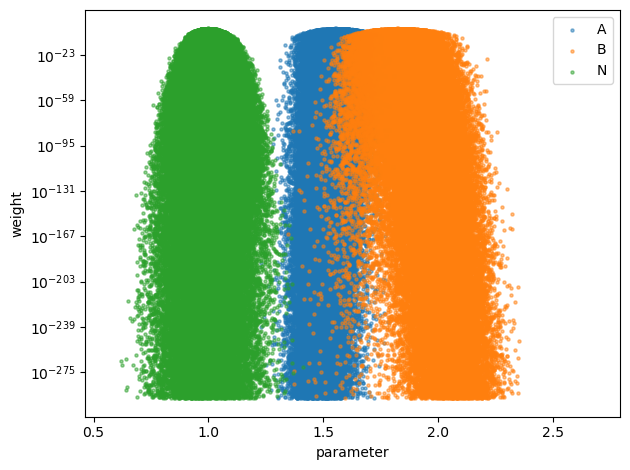

In [494]:
fig, ax = plt.subplots()
ax.scatter(A, w, s=5, alpha=.5, label="A")
ax.scatter(B, w, s=5, alpha=.5, label="B")
ax.scatter(N, w, s=5, alpha=.5, label="N")
ax.legend(loc=1)
ax.set(yscale="log", xlabel="parameter", ylabel="weight")
fig.tight_layout()

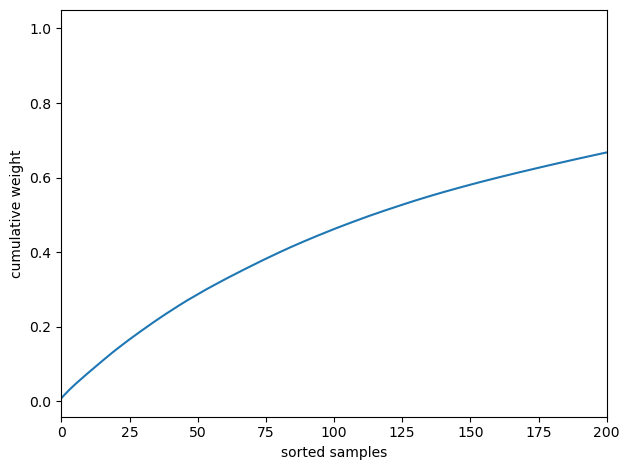

In [495]:
fig, ax = plt.subplots()
w_sorted = np.sort(w)[::-1]
ax.plot(np.cumsum(w_sorted))
ax.set(xlabel="sorted samples", ylabel="cumulative weight", xlim=[0, 200])
fig.tight_layout()

In [496]:
A_post_mean = np.sum(w * A)
A_post_std = np.sqrt(np.sum(w * (A - A_post_mean)**2))

print(
    A_post_mean,
    A_post_std / A_post_mean * 100
)

B_post_mean = np.sum(w * B)
B_post_std = np.sqrt(np.sum(w * (B - B_post_mean)**2))

print(
    B_post_mean,
    B_post_std / B_post_mean * 100
)

N_post_mean = np.sum(w * N)
N_post_std = np.sqrt(np.sum(w * (N - N_post_mean)**2))

print(
    N_post_mean,
    N_post_std / N_post_mean * 100
)

cov_AB = np.sum(w * (A - A_post_mean) * (B - B_post_mean))
corr_AB = cov_AB / (A_post_std * B_post_std)
print(corr_AB)

cov_AN = np.sum(w * (A - A_post_mean) * (N - N_post_mean))
corr_AN = cov_AN / (A_post_std * N_post_std)
print(corr_AN)

cov_BN = np.sum(w * (B - B_post_mean) * (N - N_post_mean))
corr_BN = cov_BN / (B_post_std * N_post_std)
print(corr_BN)

1.5584842101674095 2.0782817388635086
1.8321753259516194 2.2663356636005565
0.9994812967266332 1.8460264645681326
0.9622969225164988
-0.7929781384193912
-0.6941948242864688


<Axes: >

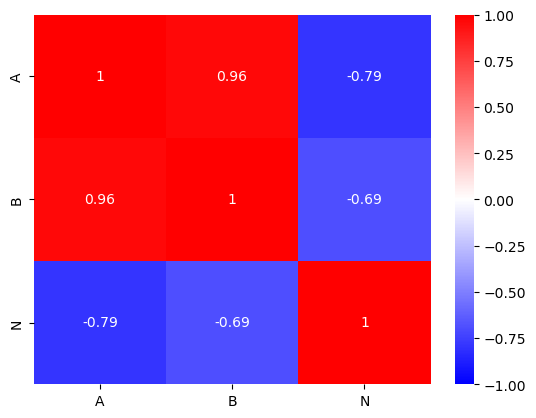

In [497]:
corr_matrix = pd.DataFrame([
    [1,       corr_AB, corr_AN],
    [corr_AB, 1,       corr_BN],
    [corr_AN, corr_BN, 1      ],
], index=["A", "B", "N"], columns=["A", "B", "N"])
sns.heatmap(corr_matrix, cmap="bwr", vmin=-1, vmax=1, annot=True)

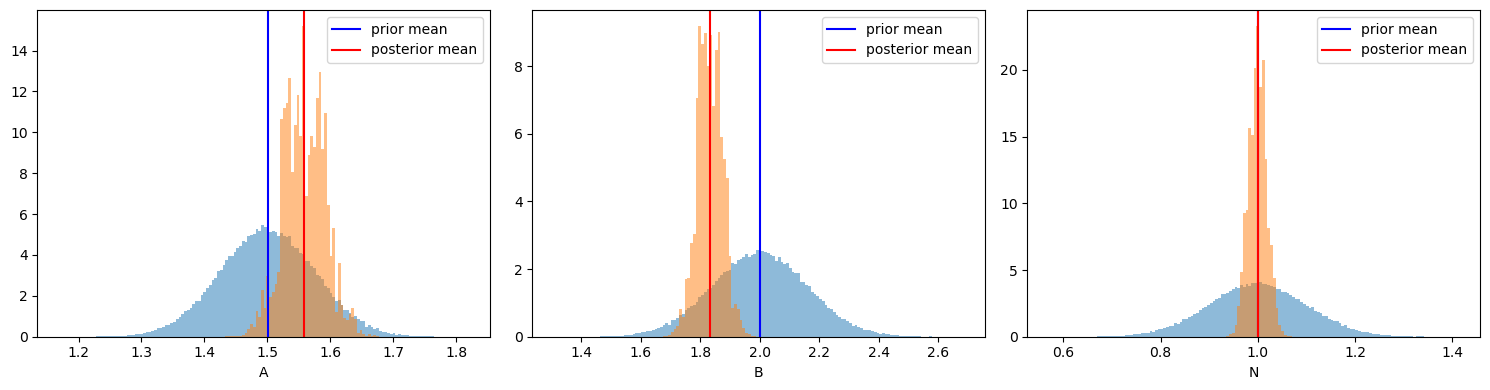

In [498]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

bins = 150

ax = axs[0]
ax.hist(A, bins=bins, density=True, alpha=.5)
ax.hist(A, bins=bins, weights=w, density=True, alpha=.5)
ax.axvline(np.mean(A), color='b', label='prior mean')
ax.axvline(np.sum(w * A), color='r', label='posterior mean')
ax.set(xlabel="A")
ax.legend(loc=1)

ax = axs[1]
ax.hist(B, bins=bins, density=True, alpha=.5)
ax.hist(B, bins=bins, weights=w, density=True, alpha=.5)
ax.axvline(np.mean(B), color='b', label='prior mean')
ax.axvline(np.sum(w * B), color='r', label='posterior mean')
ax.set(xlabel="B")
ax.legend(loc=1)

ax = axs[2]
ax.hist(N, bins=bins, density=True, alpha=.5)
ax.hist(N, bins=bins, weights=w, density=True, alpha=.5)
ax.axvline(np.mean(N), color='b', label='prior mean')
ax.axvline(np.sum(w * N), color='r', label='posterior mean')
ax.set(xlabel="N")
ax.legend(loc=1)

fig.tight_layout()